In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [4]:
df=pd.read_csv("tips.csv")

In [6]:
df.head()

,total_bill,tip,sex,smoker,day,time,size,price_per_person,Payer Name,CC Number,Payment ID
0,16.99,1.01,Female,No,Sun,Dinner,2,8.49,Christy Cunningham,3560325168603410,Sun2959
1,10.34,1.66,Male,No,Sun,Dinner,3,3.45,Douglas Tucker,4478071379779230,Sun4608
2,21.01,3.50,Male,No,Sun,Dinner,3,7.00,Travis Walters,6011812112971322,Sun4458
3,23.68,3.31,Male,No,Sun,Dinner,2,11.84,Nathaniel Harris,4676137647685994,Sun5260
4,24.59,3.61,Female,No,Sun,Dinner,4,6.15,Tonya Carter,4832732618637221,Sun2251


In [7]:
df.isnull().sum()

total_bill          0
tip                 0
sex                 0
smoker              0
day                 0
time                0
size                0
price_per_person    0
Payer Name          0
CC Number           0
Payment ID          0
dtype: int64

In [8]:
df.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size',
       'price_per_person', 'Payer Name', 'CC Number', 'Payment ID'],
      dtype='object')

In [9]:
df=pd.get_dummies(df, columns=['sex', 'smoker', 'day', 'time',],drop_first=True) 

In [14]:
df=df.drop(['price_per_person', 'Payer Name', 'CC Number', 'Payment ID'],axis=1)

In [15]:
df.head()

,total_bill,tip,size,sex_Male,smoker_Yes,day_Sat,day_Sun,day_Thur,time_Lunch
0,16.99,1.01,2,False,False,False,True,False,False
1,10.34,1.66,3,True,False,False,True,False,False
2,21.01,3.50,3,True,False,False,True,False,False
3,23.68,3.31,2,True,False,False,True,False,False
4,24.59,3.61,4,False,False,False,True,False,False


In [16]:
x=df.drop(columns=['tip'])
y=df['tip']

In [17]:
x

,total_bill,size,sex_Male,smoker_Yes,day_Sat,day_Sun,day_Thur,time_Lunch
0,16.99,2,False,False,False,True,False,False
1,10.34,3,True,False,False,True,False,False
2,21.01,3,True,False,False,True,False,False
3,23.68,2,True,False,False,True,False,False
4,24.59,4,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...
239,29.03,3,True,False,True,False,False,False
240,27.18,2,False,True,True,False,False,False
241,22.67,2,True,True,True,False,False,False
242,17.82,2,True,False,True,False,False,False


In [22]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

In [40]:
x_train, x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=.20,random_state=12)

In [41]:
#multiple linear regression
ML=LinearRegression()
ML.fit(x_train,y_train)
y_pred_ML=ML.predict(x_test)
ML_mse=mean_squared_error(y_test,y_pred_ML)
ML_mse

1.0186729931198935

In [54]:
#ridge reg
ridge=Ridge(alpha=2.0) # alpha is regulariztion strength(lambda)
ridge.fit(x_train,y_train)
y_pred_ridge=ridge.predict(x_test)
ridge_mse=mean_squared_error(y_test,y_pred_ridge)
ridge_mse

1.0154839537259854

In [56]:
#lasso reg
lasso=Lasso(alpha=2.0) # alpha is regulariztion strength(lambda)
lasso.fit(x_train,y_train)
y_pred_lasso=lasso.predict(x_test)
lasso_mse=mean_squared_error(y_test,y_pred_lasso)
lasso_mse
#accuracy increses bcz some features dropped

1.9144952515128342

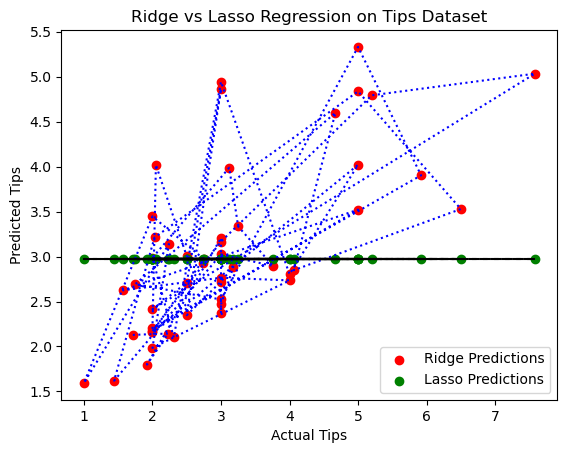

In [60]:
plt.scatter(y_test, y_pred_ridge, color='red', label='Ridge Predictions')
plt.plot(y_test, y_pred_ridge, color='blue',linestyle='dotted')
plt.scatter(y_test, y_pred_lasso, color='green', label='Lasso Predictions')
plt.plot(y_test, y_pred_lasso, color='black', linestyle='dashed')
plt.legend()
plt.xlabel("Actual Tips")
plt.ylabel("Predicted Tips")
plt.title("Ridge vs Lasso Regression on Tips Dataset")
plt.show()

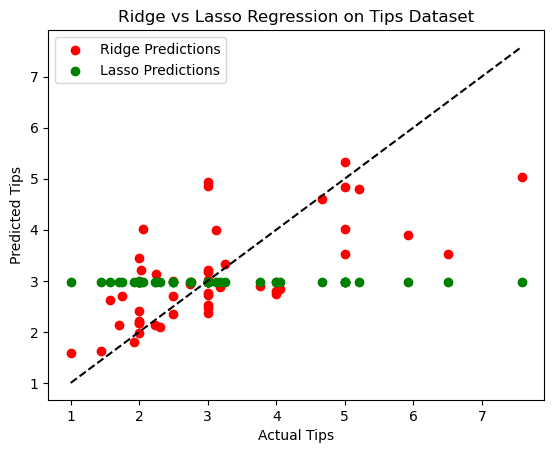

In [61]:
plt.scatter(y_test, y_pred_ridge, color='red', label='Ridge Predictions')
plt.scatter(y_test, y_pred_lasso, color='green', label='Lasso Predictions')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)],
         color='black', linestyle='dashed')
plt.legend()
plt.xlabel("Actual Tips")
plt.ylabel("Predicted Tips")
plt.title("Ridge vs Lasso Regression on Tips Dataset")
plt.show()